# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../../").resolve()
sys.path.append(str(module_path))

from src.data.simulation import generate_dict_of_combs
from src.data.exploration import *
from src.data.operation import import_non_spatial_data_frame
from src.utils.config import  base_pairs, third_values

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.parent.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data loading

In [3]:
dict_of_combs = generate_dict_of_combs(base_pairs, third_values)
connection_link_var = repo_path_r_string + r'\data\simulations\experiment_001.sqlite'
dict_of_gdfs = {}

conn = sqlite3.connect(connection_link_var)

for name in dict_of_combs:

        df = import_non_spatial_data_frame(
            conn=conn,
            df_to_return_name=name
        )

        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df["x"], df["y"]),
            crs="EPSG:3857"
        )

        dict_of_gdfs[name] = gdf

conn.close()

In [4]:
df_results = pd.read_csv(repo_path_r_string + r'\results\data\experiment_001.csv')

In [5]:
df_results

,Unnamed: 0,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,0,100.000000,treated_inner_ring,1.500000,1.159941,0.178888,1.706875,0.067303,1.676148,0.075548,1.685370,0.238042
1,1,100.000000,treated_outer_ring1,0.725939,0.258024,0.069869,0.744538,0.105783,0.853451,0.114583,0.819003,0.231775
2,2,100.000000,treated_outer_ring2,0.564862,0.535985,0.094476,0.815848,0.030703,0.514477,0.042948,0.759354,0.208357
3,3,100.000000,treated_outer_ring3,0.147708,0.057846,0.052953,0.089142,0.039850,0.353107,0.023728,0.130569,0.179064
4,4,100.000000,treated_outer_ring4,0.021262,0.085067,0.058451,0.125882,0.023274,0.246985,0.016831,0.132992,0.169956
5,5,66.666667,treated_inner_ring,1.500000,1.123863,0.183610,1.437576,0.051829,1.440984,0.060559,1.512602,0.237223
6,6,66.666667,treated_outer_ring1,0.860775,0.922322,0.115991,0.985082,0.062063,1.128481,0.039459,1.226332,0.230771
7,7,66.666667,treated_outer_ring2,0.646328,0.460595,0.092421,0.812734,0.070244,0.595761,0.017747,0.812370,0.208364
8,8,66.666667,treated_outer_ring3,0.158756,0.014744,0.037685,-0.054898,0.021936,0.386464,0.010135,-0.072497,0.178655
9,9,66.666667,treated_outer_ring4,0.021295,0.003188,0.033378,-0.028798,0.022197,0.286157,0.005699,0.023358,0.168915


# Data transformation

In [6]:
model_dict = {
    "mSlearn": ("att_mSlearn", "se_mSlearn"),
    "mCF": ("att_mCF", "se_mCF"),
    "dCF": ("att_dCF", "se_dCF"),
    "mDiD": ("att_mDiD", "se_mDiD"),
}

df_sig, df_flagged = compute_significance_share(
    df=df_results,
    parameter_col="ring",
    model_dict=model_dict
)

df_sig2, df_flagged2 = compute_significance_share(
    df=df_results[df_results['ring'] == 'treated_inner_ring'],
    parameter_col="effect_size",
    model_dict=model_dict
)

df_sig3, df_flagged3 = compute_significance_share(
    df=df_results[df_results['ring'] == 'treated_outer_ring3'],
    parameter_col="effect_size",
    model_dict=model_dict
)

In [7]:
df_sig3

,effect_size,n,mSlearn_sig_share,mCF_sig_share,dCF_sig_share,mDiD_sig_share
0,25.000000,1,0.0,0.0,1.0,0.0
1,28.571429,1,0.0,0.0,1.0,0.0
2,50.000000,1,1.0,1.0,1.0,0.0
3,66.666667,1,0.0,0.0,1.0,0.0
4,100.000000,1,1.0,1.0,1.0,0.0


In [8]:
df_sig

,ring,n,mSlearn_sig_share,mCF_sig_share,dCF_sig_share,mDiD_sig_share
0,treated_inner_ring,5,1.0,1.0,1.0,1.0
1,treated_outer_ring1,5,1.0,1.0,1.0,1.0
2,treated_outer_ring2,5,0.8,1.0,1.0,0.8
3,treated_outer_ring3,5,0.4,0.4,1.0,0.0
4,treated_outer_ring4,5,0.2,0.4,1.0,0.2


# Visualizations

## Model setup

<Axes: >

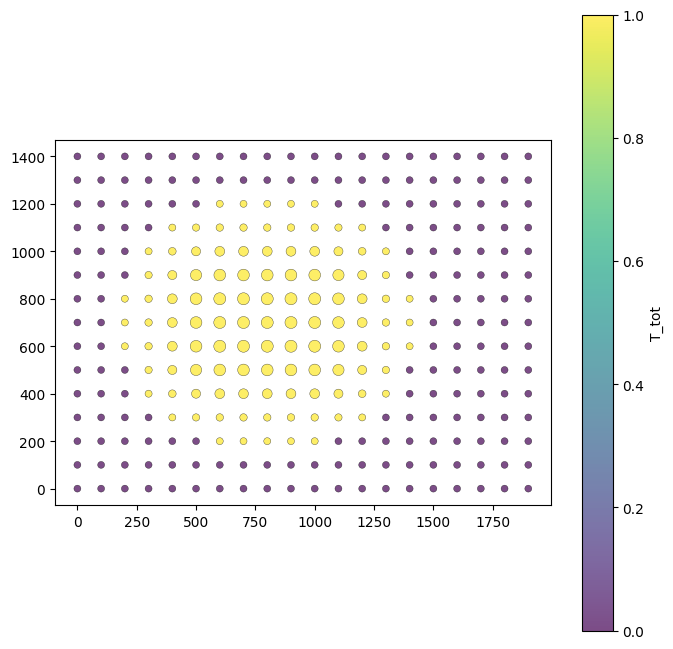

In [9]:
temp_gdf = dict_of_gdfs[list(dict_of_gdfs.keys())[0]].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

## Model parameters

C:\Users\andre\Desktop\IDS\02_VS_code\03_comparing_causal_ML_models_with_spatial_effects\src\data\exploration.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


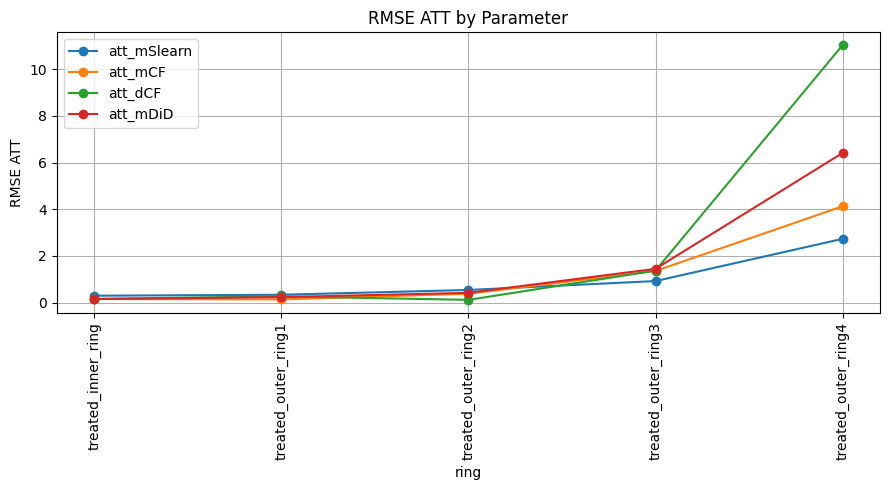

In [10]:
plot_rmse_att(
    df=df_results,
    parameter_col="ring",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD'],
    title_arg = "RMSE ATT by Parameter",
    y_axis_title = "RMSE ATT",
    rotate_x_labels=True
)

C:\Users\andre\Desktop\IDS\02_VS_code\03_comparing_causal_ML_models_with_spatial_effects\src\data\exploration.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


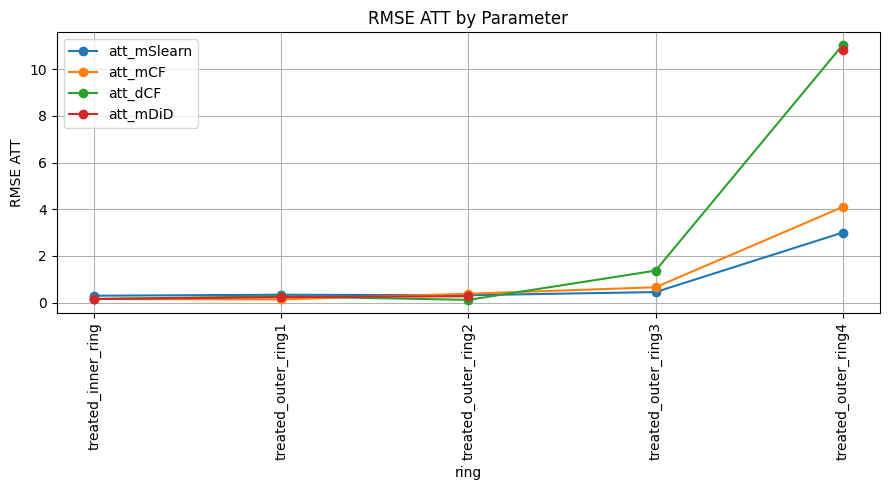

In [11]:
plot_rmse_att(
    df=df_flagged,
    parameter_col="ring",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD'],
    title_arg = "RMSE ATT by Parameter",
    y_axis_title = "RMSE ATT",
    rotate_x_labels=True
)